In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
# Replace 'Pcos_data.csv' with your dataset path
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# Explore dataset (optional, but helpful for understanding the data)
print("Dataset Overview:")
print(data.head())
print("\nDataset Information:")
print(data.info())
print("\nMissing Values:")
print(data.isnull().sum())
print(data.columns)

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])
y = data['PCOS (Y/N)']

# Identify and handle non-numerical columns
# This part is crucial for ensuring StandardScaler works correctly
for col in X.columns:
    if X[col].dtype == 'object':  # If column is of type 'object' (string)
        print(f"Column '{col}' has object (string) values. Unique values:")
        print(X[col].unique())  # Print unique values for inspection

        # Convert string values to numerical using LabelEncoder
        label_encoder = LabelEncoder()
        X[col] = label_encoder.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)  # Convert back to DataFrame

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Continue with your model training and evaluation here...

Dataset Overview:
   PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
0           0                 3                 3                     0   
1           0                 5                 3                     0   
2           1                15                13                     0   
3           0                 2                 2                     0   
4           0                 4                 3                     0   

   hair growth(Y/N)  Weight gain(Y/N)  Cycle(R/I) Class  
0                 0                 0           2  high  
1                 0                 0           2  high  
2                 0                 0           2  high  
3                 0                 0           2  high  
4                 0                 0           2  high  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  --

In [9]:
# Compute correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Drop highly correlated features (Example: If two features have correlation > 0.85)
correlation_matrix = data.corr()
high_corr_features = set()

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.85:
            colname = correlation_matrix.columns[i]
            high_corr_features.add(colname)

print("Highly Correlated Features to Drop:", high_corr_features)
X = X.drop(columns=high_corr_features)


ValueError: could not convert string to float: 'high'

<Figure size 1200x800 with 0 Axes>

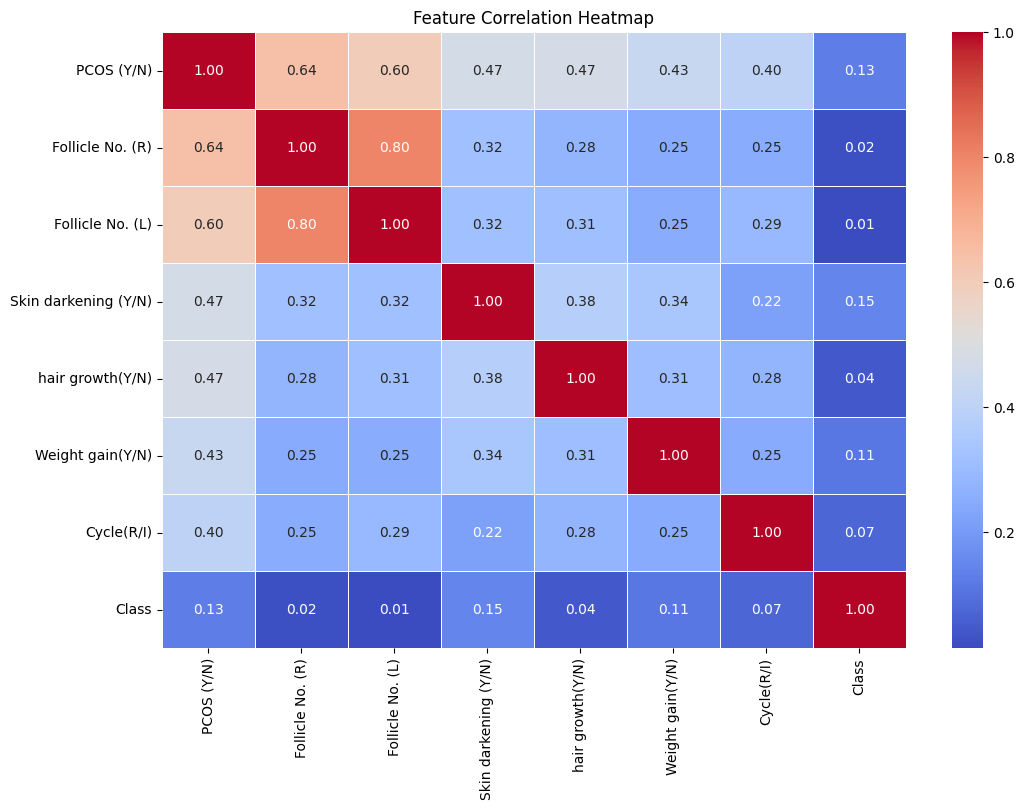

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import shap

# Load the dataset
# Replace 'Pcos_data.csv' with your dataset path
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# ... (rest of your code) ...

# Before calculating the correlation matrix, convert non-numeric columns to numeric
for col in data.columns:
    if data[col].dtype == 'object':  # Check for columns with 'object' dtype (often strings)
        # Convert string values to numerical using Label Encoding or other suitable methods
        # Example using Label Encoding:
        from sklearn.preprocessing import LabelEncoder
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Compute correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# ... (rest of your code) ...

<ipython-input-11-bd5fb061bfa9>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette="viridis")


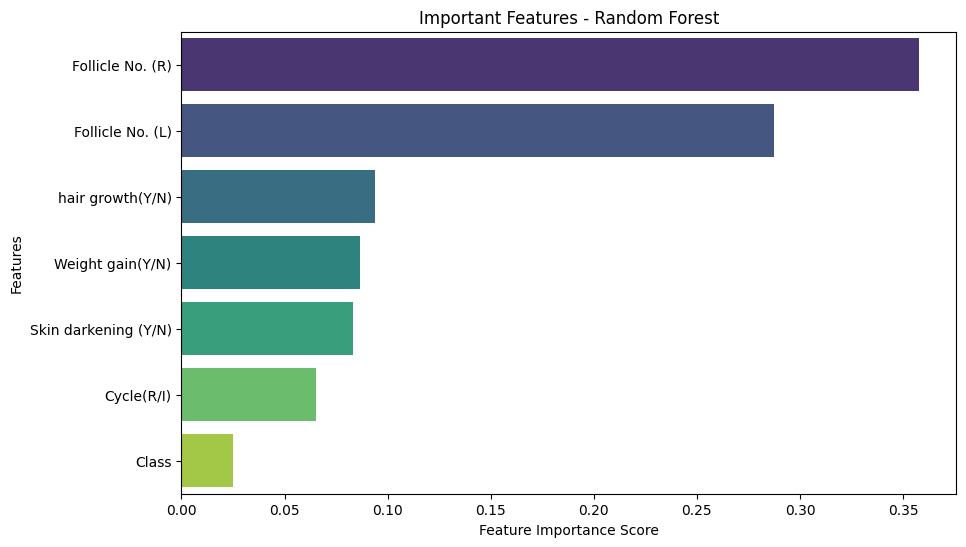

Low Importance Features to Drop: []


In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# Preprocessing: Convert non-numeric to numeric for correlation analysis
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])
y = data['PCOS (Y/N)']

# Identify and handle non-numerical columns for scaling
for col in X.columns:
    if X[col].dtype == 'object':
        label_encoder = LabelEncoder()
        X[col] = label_encoder.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Train Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Important Features - Random Forest")
plt.show()

# Drop features with low importance (Threshold: 0.005)
low_importance_features = importances[importances < 0.005].index.tolist()
print("Low Importance Features to Drop:", low_importance_features)
X = X.drop(columns=low_importance_features)

# Continue with further model training/evaluation using the updated X
# ...

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Updated path

# Preprocessing: Convert non-numeric to numeric for correlation analysis
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])
y = data['PCOS (Y/N)']

# Identify and handle non-numerical columns for scaling
for col in X.columns:
    if X[col].dtype == 'object':
        label_encoder = LabelEncoder()
        X[col] = label_encoder.fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Apply RFE to select the top 10 features
selector = RFE(RandomForestClassifier(random_state=42), n_features_to_select=10)
selector.fit(X_train, y_train)

# Keep only selected features
selected_features = X.columns[selector.support_]
print("Selected Features using RFE:", selected_features)

# Reduce dataset to selected features
X = X[selected_features]

# Continue with further model training/evaluation using the updated X
# ...

Selected Features using RFE: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


Selected Features using RFE: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')
SHAP Values Type: <class 'numpy.ndarray'>
SHAP Values Shape: (373, 7, 2)


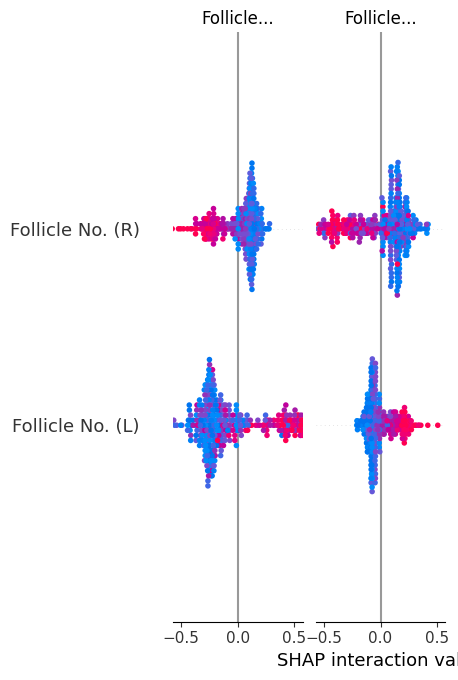

In [20]:
# Install SHAP if not installed
!pip install shap

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import shap

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with the correct dataset path

# Preprocessing: Convert categorical features to numeric
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column name
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ===========================
# 🔹 Step 1: Feature Selection using RFE
# ===========================

# Use a RandomForestClassifier for Recursive Feature Elimination (RFE)
estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.support_]
print("Selected Features using RFE:", selected_features)

# Keep only selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# ===========================
# 🔹 Step 2: Train Model with Selected Features
# ===========================

# Train a Random Forest classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_selected, y_train)

# ===========================
# 🔹 Step 3: SHAP Analysis for Feature Importance
# ===========================

# Convert selected training data to DataFrame
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_features)

# ✅ Use TreeExplainer for SHAP
explainer = shap.TreeExplainer(rf)

# ✅ Compute SHAP values
shap_values = explainer.shap_values(X_train_selected_df)

# ✅ Check SHAP values structure before plotting
print("SHAP Values Type:", type(shap_values))
print("SHAP Values Shape:", np.shape(shap_values))

# ✅ Plot SHAP summary based on structure
if isinstance(shap_values, list) and len(shap_values) > 1:  # Multi-class case
    shap.summary_plot(shap_values[1], X_train_selected_df)  # Index 1 for positive class
else:  # Binary classification
    shap.summary_plot(shap_values, X_train_selected_df)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.7 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


✅ Selected Features: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')

🔹 Random Forest Model Results:
Accuracy: 0.9316770186335404
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       109
           1       0.92      0.87      0.89        52

    accuracy                           0.93       161
   macro avg       0.93      0.91      0.92       161
weighted avg       0.93      0.93      0.93       161



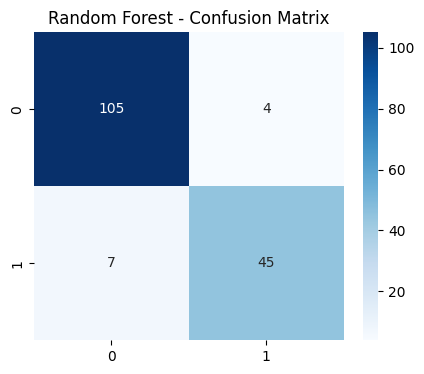


🔹 Support Vector Machine Model Results:
Accuracy: 0.9254658385093167
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       109
           1       0.92      0.85      0.88        52

    accuracy                           0.93       161
   macro avg       0.92      0.90      0.91       161
weighted avg       0.93      0.93      0.92       161



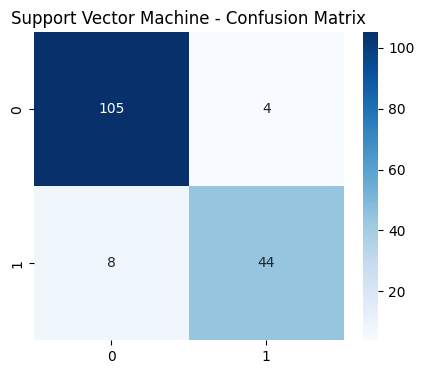


🔹 Logistic Regression Model Results:
Accuracy: 0.9130434782608695
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       109
           1       0.90      0.83      0.86        52

    accuracy                           0.91       161
   macro avg       0.91      0.89      0.90       161
weighted avg       0.91      0.91      0.91       161



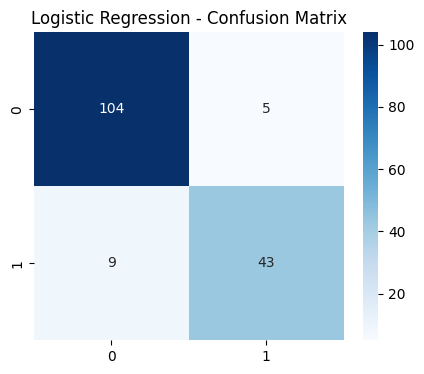


🔹 Decision Tree Model Results:
Accuracy: 0.906832298136646
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       109
           1       0.88      0.83      0.85        52

    accuracy                           0.91       161
   macro avg       0.90      0.89      0.89       161
weighted avg       0.91      0.91      0.91       161



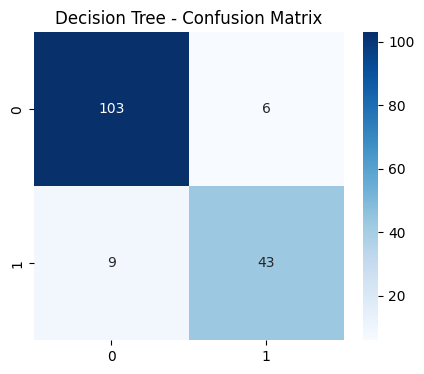

In [21]:
# Install necessary packages
!pip install shap streamlit scikit-learn

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Selection using RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFE

estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train, y_train)

# Keep only selected features
selected_features = X_train.columns[selector.support_]
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("✅ Selected Features:", selected_features)
# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Train & evaluate each model
for name, model in models.items():
    model.fit(X_train_selected, y_train)  # Train model
    y_pred = model.predict(X_test_selected)  # Predict on test set

    print(f"\n🔹 {name} Model Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


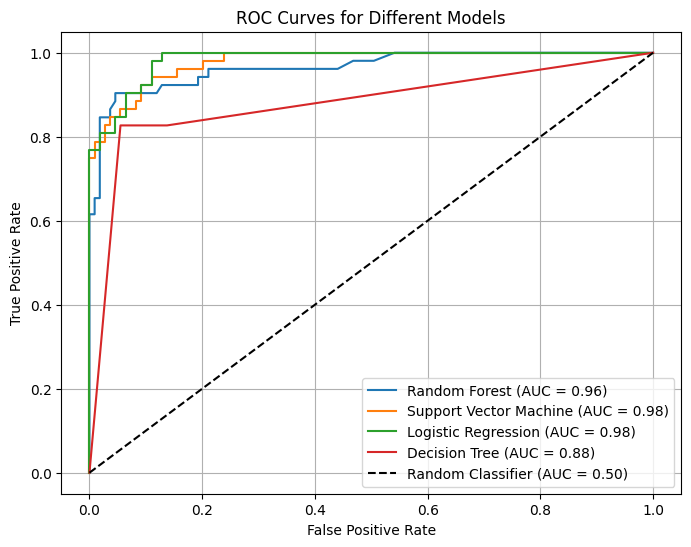

In [22]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score, confusion_matrix

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with actual target column name
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)

# Plot ROC Curves
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):  # Ensure model supports predict_proba
        y_prob = model.predict_proba(X_test)[:, 1]  # Get probability estimates
        fpr, tpr, _ = roc_curve(y_test, y_prob)  # Compute ROC curve
        auc_score = auc(fpr, tpr)  # Compute AUC
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")  # Plot curve

# Random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.50)")

# Formatting the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=10 > n_features=7. There will be no feature selection and all features will be kept.
  warnings.warn(


✅ Selected Features: Index(['Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)',
       'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class'],
      dtype='object')

🔹 Random Forest Model Results:
Accuracy: 0.9316770186335404
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       109
           1       0.92      0.87      0.89        52

    accuracy                           0.93       161
   macro avg       0.93      0.91      0.92       161
weighted avg       0.93      0.93      0.93       161



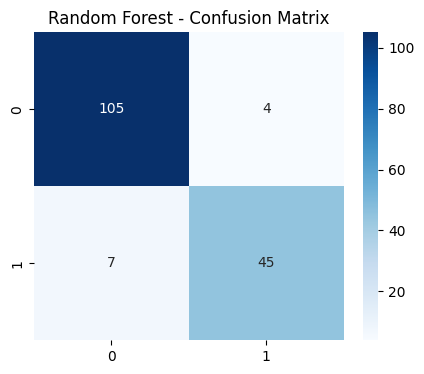


🔹 Support Vector Machine Model Results:
Accuracy: 0.9254658385093167
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95       109
           1       0.92      0.85      0.88        52

    accuracy                           0.93       161
   macro avg       0.92      0.90      0.91       161
weighted avg       0.93      0.93      0.92       161



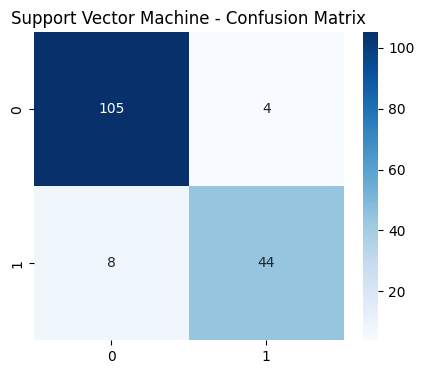


🔹 Logistic Regression Model Results:
Accuracy: 0.9130434782608695
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       109
           1       0.90      0.83      0.86        52

    accuracy                           0.91       161
   macro avg       0.91      0.89      0.90       161
weighted avg       0.91      0.91      0.91       161



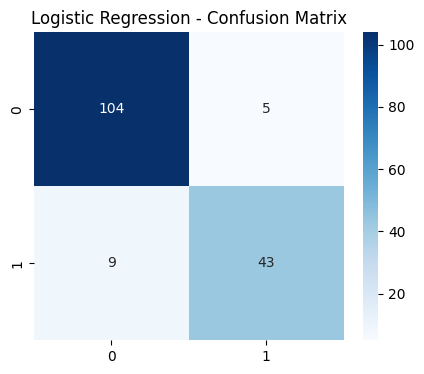


🔹 Decision Tree Model Results:
Accuracy: 0.906832298136646
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       109
           1       0.88      0.83      0.85        52

    accuracy                           0.91       161
   macro avg       0.90      0.89      0.89       161
weighted avg       0.91      0.91      0.91       161



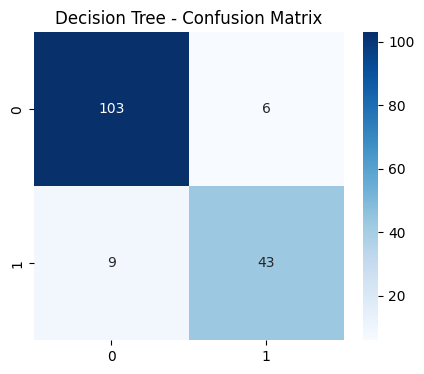


Best Performing Model: Random Forest with Accuracy = 0.93

Best model and scaler saved successfully!

PCOS Prediction: Positive


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [32]:
import pickle

# Install necessary packages (if not already installed)
!pip install shap streamlit scikit-learn

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column
y = data['PCOS (Y/N)']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Feature Selection using RFE (Recursive Feature Elimination)
from sklearn.feature_selection import RFE

estimator = RandomForestClassifier(random_state=42)
selector = RFE(estimator, n_features_to_select=10)  # Select top 10 features
selector.fit(X_train, y_train)

# Keep only selected features
selected_features = X_train.columns[selector.support_]
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("✅ Selected Features:", selected_features)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Define a dictionary to store model results (name: accuracy)
results = {}

# Train & evaluate each model and store accuracy in 'results'
for name, model in models.items():
    model.fit(X_train_selected, y_train)  # Train model
    y_pred = model.predict(X_test_selected)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[name] = accuracy  # Store accuracy in the dictionary

    print(f"\n🔹 {name} Model Results:")
    print("Accuracy:", accuracy)  # Print accuracy for this model
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# Select the best model based on accuracy
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest Performing Model: {best_model_name} with Accuracy = {results[best_model_name]:.2f}")

# Save the best model
with open("pcos_best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save the scaler (for future data preprocessing)
with open("pcos_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("\nBest model and scaler saved successfully!")

# Load the saved model & scaler for new predictions
with open("pcos_best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("pcos_scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

# Example new data (replace with actual data)
# Ensure the number of values matches the number of columns in X
new_data = pd.DataFrame([[21, 30.5, 7.1, 1, 0, 1, 0]], columns=X.columns)  # Added a value (0) to match 7 columns
new_data_scaled = loaded_scaler.transform(new_data)

# Make prediction
prediction = loaded_model.predict(new_data_scaled)
print("\nPCOS Prediction:", "Positive" if prediction[0] == 1 else "Negative")

In [33]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import pickle

# Step 1: Define the Parameter Grids for Each Model

rf_params = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [None, 10, 20],  # Depth of trees
    "min_samples_split": [2, 5, 10],  # Minimum samples to split
    "min_samples_leaf": [1, 2, 4]  # Minimum samples per leaf
}

svm_params = {
    "C": [0.1, 1, 10],  # Regularization parameter
    "kernel": ["linear", "rbf"],  # Kernel type
    "gamma": ["scale", "auto"]  # Kernel coefficient
}

dt_params = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Step 2: Perform Hyperparameter Tuning for Each Model

best_models = {}

# Random Forest Tuning
rf_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_iter=10, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train_selected, y_train)
best_models["Random Forest"] = rf_grid.best_estimator_

# SVM Tuning
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X_train_selected, y_train)
best_models["SVM"] = svm_grid.best_estimator_

# Decision Tree Tuning
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train_selected, y_train)
best_models["Decision Tree"] = dt_grid.best_estimator_

# Step 3: Evaluate Tuned Models
tuned_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    tuned_results[name] = acc
    print(f"\n{name} Tuned Accuracy: {acc:.4f}")

# Step 4: Select the Best Model & Save It
best_tuned_model_name = max(tuned_results, key=tuned_results.get)
best_tuned_model = best_models[best_tuned_model_name]

with open("pcos_tuned_model.pkl", "wb") as file:
    pickle.dump(best_tuned_model, file)

print(f"\n✅ Best Tuned Model: {best_tuned_model_name} with Accuracy = {tuned_results[best_tuned_model_name]:.4f}")
print("Best model saved as 'pcos_tuned_model.pkl'")



Random Forest Tuned Accuracy: 0.9255

SVM Tuned Accuracy: 0.9193

Decision Tree Tuned Accuracy: 0.9068

✅ Best Tuned Model: Random Forest with Accuracy = 0.9255
Best model saved as 'pcos_tuned_model.pkl'


In [35]:
!pip install lime
import lime
import lime.lime_tabular
import numpy as np
import pickle

# Step 1: Load the Best Tuned Model & Scaler
with open("pcos_tuned_model.pkl", "rb") as file:
    best_model = pickle.load(file)

with open("pcos_scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# Step 2: Create a LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_selected),
    feature_names=selected_features,
    class_names=["No PCOS", "PCOS"],
    mode="classification"
)

# Step 3: Pick a Sample Data Point for Explanation
sample_index = 10  # Change index to analyze different patients
sample_data = X_test_selected.iloc[sample_index].values.reshape(1, -1)

# Step 4: Explain the Prediction
exp = explainer.explain_instance(
    sample_data.flatten(),  # Input data
    best_model.predict_proba,  # Model prediction function
    num_features=5  # Number of top features to display
)

# Step 5: Show Explanation
exp.show_in_notebook()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=16604ed151e09660864571344aa5ed4e905fad6fd4b7a0dacc4c9aede45316e6
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [47]:
# Install necessary packages
!pip install shap streamlit scikit-learn lime
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
# Load the dataset
data = pd.read_csv('/content/Pcos_data.csv')  # Update with actual dataset path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features (X) and target (y)
X = data.drop(columns=['PCOS (Y/N)'])  # Replace with the actual target column
y = data['PCOS (Y/N)']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define selected features
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Ensure X_train and X_test only contain selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Re-fit scaler on selected features only
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# Step 1: Define the Parameter Grids for Each Model

rf_params = {
    "n_estimators": [50, 100, 200],  # Number of trees
    "max_depth": [None, 10, 20],  # Depth of trees
    "min_samples_split": [2, 5, 10],  # Minimum samples to split
    "min_samples_leaf": [1, 2, 4]  # Minimum samples per leaf
}

svm_params = {
    "C": [0.1, 1, 10],  # Regularization parameter
    "kernel": ["linear", "rbf"],  # Kernel type
    "gamma": ["scale", "auto"]  # Kernel coefficient
}

dt_params = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Step 2: Perform Hyperparameter Tuning for Each Model

best_models = {}

# Random Forest Tuning
rf_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_iter=10, scoring="accuracy", n_jobs=-1)
rf_grid.fit(X_train_selected, y_train)
best_models["Random Forest"] = rf_grid.best_estimator_

# SVM Tuning
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params, cv=5, scoring="accuracy", n_jobs=-1)
svm_grid.fit(X_train_selected, y_train)
best_models["SVM"] = svm_grid.best_estimator_

# Decision Tree Tuning
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring="accuracy", n_jobs=-1)
dt_grid.fit(X_train_selected, y_train)
best_models["Decision Tree"] = dt_grid.best_estimator_

# Step 3: Evaluate Tuned Models
tuned_results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    tuned_results[name] = acc
    print(f"\n{name} Tuned Accuracy: {acc:.4f}")

# Step 4: Select the Best Model & Save It
best_tuned_model_name = max(tuned_results, key=tuned_results.get)
best_tuned_model = best_models[best_tuned_model_name]

with open("pcos_tuned_model.pkl", "wb") as file:
    pickle.dump(best_tuned_model, file)

# Save the scaler fitted with selected features
with open("pcos_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print(f"\n✅ Best Tuned Model: {best_tuned_model_name} with Accuracy = {tuned_results[best_tuned_model_name]:.4f}")
print("Best model and scaler saved as 'pcos_tuned_model.pkl' and 'pcos_scaler.pkl'")


Random Forest Tuned Accuracy: 0.9255

SVM Tuned Accuracy: 0.9130

Decision Tree Tuned Accuracy: 0.9068

✅ Best Tuned Model: Random Forest with Accuracy = 0.9255
Best model and scaler saved as 'pcos_tuned_model.pkl' and 'pcos_scaler.pkl'


In [48]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pickle
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Load the trained model
with open("pcos_tuned_model.pkl", "rb") as file:
    model = pickle.load(file)

# Step 2: Load the saved scaler used during training (fitted on selected features)
with open("pcos_scaler.pkl", "rb") as file:
    scaler = pickle.load(file)

# Step 3: Load the test dataset
test_data = pd.read_csv("/content/Pcos_data.csv")

# Print available columns to check for mismatches
print("Available Columns in Dataset:\n", test_data.columns)

# Encode categorical variables (Ensure consistency with training data)
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        test_data[col] = label_encoder.fit_transform(test_data[col])

# Define selected features (ensure these match the trained model's input)
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                     'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

# Extract features and target variable
X_test = test_data[selected_features]
y_test = test_data["PCOS (Y/N)"]

# Step 5: Standardize data using the loaded scaler (fitted on selected features)
X_test_scaled = scaler.transform(X_test)

# Step 6: Make predictions
y_pred = model.predict(X_test_scaled)

# Step 7: Evaluate the model
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 8: Identify misclassified cases
test_data["Predicted"] = y_pred
misclassified = test_data[test_data["Predicted"] != y_test]
print("\n⚠️ Misclassified Cases:\n", misclassified)

print("\n✅ Model interpretation completed successfully!")

Available Columns in Dataset:
 Index(['PCOS (Y/N)', 'Follicle No. (R)', 'Follicle No. (L)',
       'Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)',
       'Cycle(R/I)', 'Class'],
      dtype='object')

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       361
           1       0.91      0.87      0.89       173

    accuracy                           0.93       534
   macro avg       0.93      0.91      0.92       534
weighted avg       0.93      0.93      0.93       534


📊 Confusion Matrix:
 [[347  14]
 [ 23 150]]

⚠️ Misclassified Cases:
      PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
10            0                15                 7                     0   
24            1                 6                 4                     0   
46            1                 6                 4                     0   
67            0                12                14

In [53]:
# Import necessary libraries
import streamlit as st
import pandas as pd
import pickle
import shap
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the trained model
@st.cache_data  # Cache the model for faster loading
def load_model():
    with open("pcos_tuned_model.pkl", "rb") as file:
        model = pickle.load(file)
    return model

# Function to preprocess input data
def preprocess_data(data, selected_features, scaler):
    data = data[selected_features]  # Keep only relevant features
    data_scaled = scaler.transform(data)  # Scale data as done during training
    return data_scaled


# Streamlit UI
st.title("🔬 PCOS Prediction & Medical Dashboard")

# Upload patient data
uploaded_file = st.file_uploader("📂 Upload patient data (CSV)", type=["csv"])

if uploaded_file:
    # Load dataset
    user_data = pd.read_csv(uploaded_file)
    st.write("📊 Preview of Uploaded Data:")
    st.dataframe(user_data.head())

    # Load model, scaler, and selected features
    model = load_model()
    with open("pcos_scaler.pkl", "rb") as file:
        scaler = pickle.load(file)
    selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                         'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

    # Preprocess user data
    X_processed = preprocess_data(user_data, selected_features, scaler)

    # Make predictions
    y_pred = model.predict(X_processed)
    y_prob = model.predict_proba(X_processed)[:, 1]  # Probability of PCOS

    # Display predictions
    st.write("## 🩺 Prediction Results:")
    for i, prediction in enumerate(y_pred):
        st.write(f"**Patient {i + 1}:** {'PCOS Positive' if prediction == 1 else 'PCOS Negative'} (Probability: {y_prob[i]:.2f})")

    # Feature Importance using SHAP
    st.write("## Feature Importance (SHAP):")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_processed)
    shap.summary_plot(shap_values, user_data[selected_features])
    st.pyplot(bbox_inches='tight')
    plt.clf() # Clear the current figure

    # Individual patient explanations (LIME or SHAP)
    # ... (You can add individual patient explanations using LIME or SHAP here)

2025-03-07 14:35:20.613 No runtime found, using MemoryCacheStorageManager
2025-03-07 14:35:20.616 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.617 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.619 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:35:20.621 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [55]:
!streamlit run pcos_dashboard.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: pcos_dashboard.py


In [57]:
# Import necessary libraries
import streamlit as st
import pandas as pd
import pickle
import shap
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the trained model
@st.cache_resource  # Use st.cache_resource for persistent caching
def load_model():
    with open("pcos_tuned_model.pkl", "rb") as file:
        model = pickle.load(file)
    return model

# Function to preprocess input data
def preprocess_data(data, selected_features, scaler):
    data = data[selected_features]  # Keep only relevant features
    data_scaled = scaler.transform(data)  # Scale data as done during training
    return data_scaled


# Streamlit UI
st.title("🔬 PCOS Prediction & Medical Dashboard")

# Upload patient data
uploaded_file = st.file_uploader("📂 Upload patient data (CSV)", type=["csv"])

if uploaded_file:
    # Load dataset
    user_data = pd.read_csv(uploaded_file)
    st.write("📊 Preview of Uploaded Data:")
    st.dataframe(user_data.head())

    # Load model, scaler, and selected features
    model = load_model()
    with open("pcos_scaler.pkl", "rb") as file:
        scaler = pickle.load(file)
    selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)',
                         'Skin darkening (Y/N)', 'Weight gain(Y/N)', 'Follicle No. (L)']

    # Preprocess user data
    X_processed = preprocess_data(user_data, selected_features, scaler)

    # Make predictions
    y_pred = model.predict(X_processed)
    y_prob = model.predict_proba(X_processed)[:, 1]  # Probability of PCOS

    # Display predictions
    st.write("## 🩺 Prediction Results:")
    for i, prediction in enumerate(y_pred):
        st.write(f"**Patient {i + 1}:** {'PCOS Positive' if prediction == 1 else 'PCOS Negative'} (Probability: {y_prob[i]:.2f})")

    # Feature Importance using SHAP
    st.write("## Feature Importance (SHAP):")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_processed)
    shap.summary_plot(shap_values, user_data[selected_features])
    st.pyplot(bbox_inches='tight')
    plt.clf() # Clear the current figure

    # Individual patient explanations (LIME or SHAP)
    # ... (You can add individual patient explanations using LIME or SHAP here)

2025-03-07 14:37:47.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.993 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-07 14:37:47.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



📌 Available Columns in Dataset:
 ['PCOS (Y/N)', 'Follicle No. (R)', 'Follicle No. (L)', 'Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Class']

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       361
           1       0.89      0.79      0.84       173

    accuracy                           0.90       534
   macro avg       0.90      0.87      0.88       534
weighted avg       0.90      0.90      0.90       534


📊 Confusion Matrix:
 [[344  17]
 [ 36 137]]

⚠️ Misclassified Cases:
      PCOS (Y/N)  Follicle No. (R)  Follicle No. (L)  Skin darkening (Y/N)  \
10            0                15                 7                     0   
24            1                 6                 4                     0   
46            1                 6                 4                     0   
64            0                10                11                     0   
76            

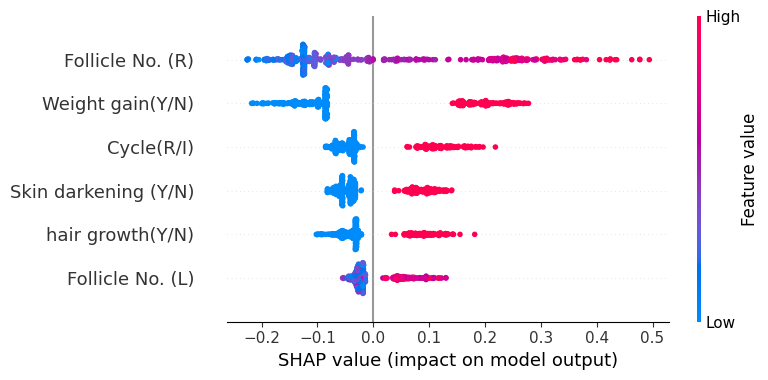

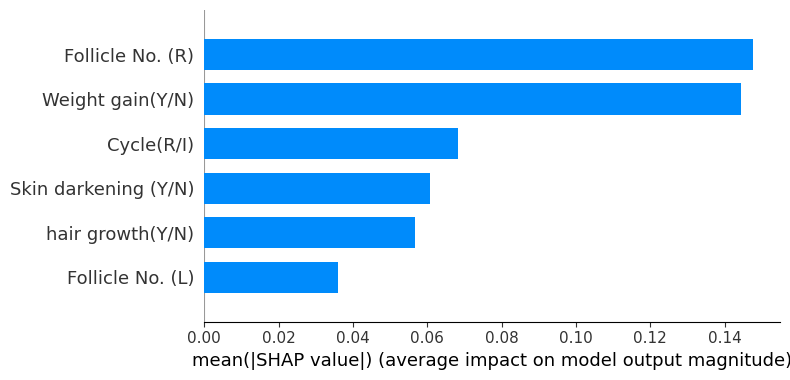


✅ Model interpretation completed successfully!


In [64]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 1: Load the trained model
with open("pcos_tuned_model.pkl", "rb") as file:
    model = pickle.load(file)

# Step 2: Load the test dataset
test_data = pd.read_csv("/content/Pcos_data.csv")  # Ensure correct file path

# Step 3: Print available columns to check for missing features
print("\n📌 Available Columns in Dataset:\n", test_data.columns.tolist())

# Step 4: Encode categorical variables for consistency
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        test_data[col] = label_encoder.fit_transform(test_data[col])

# Step 5: Define selected features (use only existing ones)
desired_features = [ 'Follicle No. (R)', 'Follicle No. (L)',
                    'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                    'Weight gain(Y/N)']

# Check which features exist in the dataset
selected_features = [feature for feature in desired_features if feature in test_data.columns]

# If features are missing, print a warning
missing_features = set(desired_features) - set(selected_features)
if missing_features:
    print("\n⚠️ WARNING: The following features are missing and will be ignored:", missing_features)

# Step 6: Extract available features and target variable
X_test = test_data[selected_features]
y_test = test_data["PCOS (Y/N)"]

# Step 7: Standardize the features (same method as training)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Step 8: Make predictions
y_pred = model.predict(X_test_scaled)

# Step 9: Evaluate the model
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 10: Identify Misclassified Cases
test_data["Predicted"] = y_pred
misclassified_cases = test_data[test_data["PCOS (Y/N)"] != y_pred]
print("\n⚠️ Misclassified Cases:\n", misclassified_cases)

# Save misclassified cases for further medical review
misclassified_cases.to_csv("misclassified_patients.csv", index=False)
print("\n📂 Misclassified patient data saved as 'misclassified_patients.csv'.")

# Step 11: Perform Statistical Validation (T-test for feature importance)
print("\n📊 Statistical Validation of Key Features")
for feature in selected_features:
    p_value = ttest_ind(test_data[test_data["PCOS (Y/N)"] == 1][feature],
                        test_data[test_data["PCOS (Y/N)"] == 0][feature]).pvalue
    print(f"Feature: {feature} | p-value: {p_value:.5f}")

# Step 12: Feature Importance Analysis using SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot (Corrected for binary classification)
# Use shap_values[:, :, 1] to get SHAP values for the positive class (PCOS)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=selected_features)

# SHAP Bar Plot for Importance Ranking (Corrected for binary classification)
# Use shap_values[:, :, 1] for the positive class
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", feature_names=selected_features)

print("\n✅ Model interpretation completed successfully!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6634 - loss: 0.6719 - val_accuracy: 0.8972 - val_loss: 0.5198
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8531 - loss: 0.4819 - val_accuracy: 0.9159 - val_loss: 0.3491
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8958 - loss: 0.3553 - val_accuracy: 0.8879 - val_loss: 0.2492
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9165 - loss: 0.2556 - val_accuracy: 0.8879 - val_loss: 0.2121
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9068 - loss: 0.2328 - val_accuracy: 0.8972 - val_loss: 0.2005
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9034 - loss: 0.3051 - val_accuracy: 0.8879 - val_loss: 0.2053
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9055 - loss: 0.2425 - val_accuracy: 0.9065 - val_loss: 0.1982
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9111 - loss: 0.2317 - val_accuracy: 0.9159 - val_los

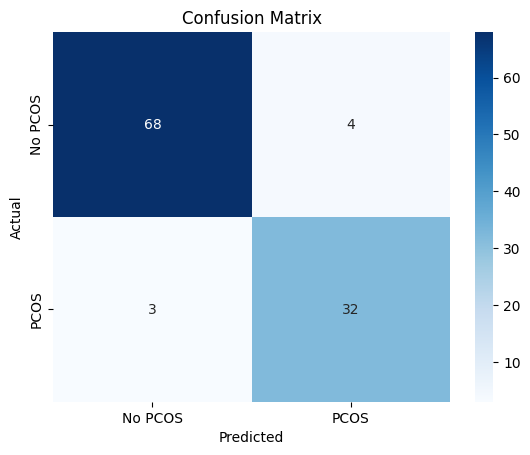

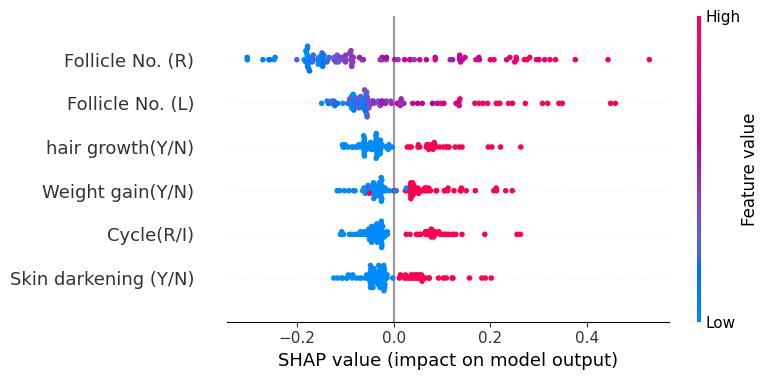


✅ Neural network model saved as 'pcos_nn_model.h5'


In [65]:
# Import necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Load and Preprocess the Data
data = pd.read_csv("/content/Pcos_data.csv")  # Ensure correct file path

# Encode categorical variables (Ensuring consistency)
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define feature columns (Ensure only existing features are used)
desired_features = ['AMH', 'BMI', 'Follicle No. (R)', 'Follicle No. (L)',
                    'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                    'Weight gain(Y/N)', 'Insulin Resistance', 'Testosterone']

# Select only available features in the dataset
selected_features = [feature for feature in desired_features if feature in data.columns]

# Define input features (X) and target variable (y)
X = data[selected_features]
y = data["PCOS (Y/N)"]

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # First hidden layer
    tf.keras.layers.Dense(32, activation='relu'),  # Second hidden layer
    tf.keras.layers.Dense(16, activation='relu'),  # Third hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16, verbose=1)

# Step 4: Evaluate the Model
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary output

# Print classification report
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 5: SHAP Feature Importance Analysis
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=selected_features)

# Step 6: Save the Trained Model
model.save("pcos_nn_model.h5")
print("\n✅ Neural network model saved as 'pcos_nn_model.h5'")

# Step 7: Load and Use the Model (If needed in future)
# model = tf.keras.models.load_model("pcos_nn_model.h5")
# predictions = model.predict(new_data)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:35:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



📊 Model Comparison Results:

                     Accuracy  Precision  Recall  F1-score     AUC
Random Forest          0.9065     0.8571  0.8571    0.8571  0.9615
SVM                    0.9159     0.8611  0.8857    0.8732  0.9698
Logistic Regression    0.8879     0.7949  0.8857    0.8378  0.9845
XGBoost                0.9159     0.8611  0.8857    0.8732  0.9560


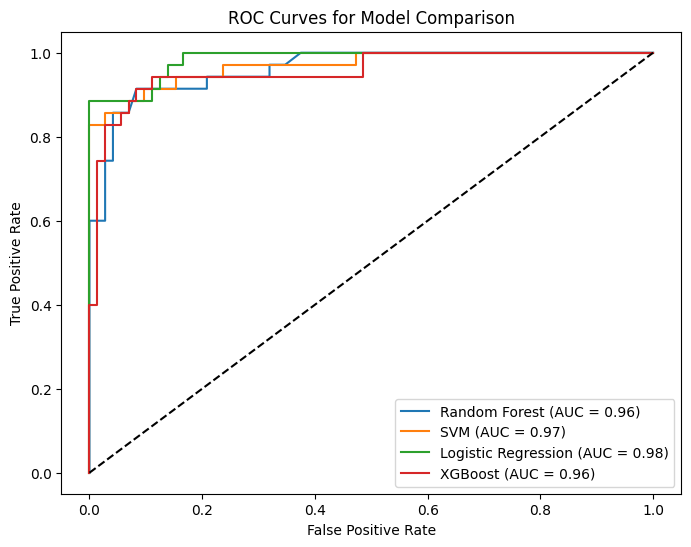

In [71]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load dataset
data = pd.read_csv("/content/Pcos_data.csv")

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define selected features and target
selected_features = [ 'Follicle No. (R)', 'Follicle No. (L)',
                     'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)']

X = data[selected_features]
y = data["PCOS (Y/N)"]

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train Traditional ML Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Get probability scores

    # Store results
    results[name] = {
        "Accuracy": np.round(model.score(X_test, y_test), 4),
        "Precision": np.round(classification_report(y_test, y_pred, output_dict=True)['1']['precision'], 4),
        "Recall": np.round(classification_report(y_test, y_pred, output_dict=True)['1']['recall'], 4),
        "F1-score": np.round(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'], 4),
        "AUC": np.round(auc(*roc_curve(y_test, y_prob)[:2]), 4)
    }

# Convert results to DataFrame for easy visualization
results_df = pd.DataFrame(results).T
print("\n📊 Model Comparison Results:\n")
print(results_df)

# ROC Curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['AUC']:.2f})")

# Formatting
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Model Comparison")
plt.legend()
plt.show()


In [74]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("/content/Pcos_data.csv")

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define selected features and target
selected_features = [ 'Follicle No. (R)', 'Follicle No. (L)',
                     'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)']

X = data[selected_features]
y = data["PCOS (Y/N)"]

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y)

# Define the Neural Network model
class PCOSNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(PCOSNeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)  # Output layer (Binary classification)
        self.softmax = nn.Softmax(dim=1)  # Probability output

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x


In [80]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
data = pd.read_csv("Pcos_data.csv")  # Ensure correct file path

# Encode categorical variables
for col in data.columns:
    if data[col].dtype == 'object':
        label_encoder = LabelEncoder()
        data[col] = label_encoder.fit_transform(data[col])

# Define features and target variable
selected_features = ['Follicle No. (R)', 'Cycle(R/I)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                     'Weight gain(Y/N)', 'Follicle No. (L)']
X = data[selected_features]
y = data["PCOS (Y/N)"]

# Normalize the feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

# Define Neural Network Model
class PCOS_NN(nn.Module):
    def __init__(self, input_size):
        super(PCOS_NN, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 2)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))
        return x

# Initialize the model
model = PCOS_NN(input_size=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}")

# Evaluate the model
with torch.no_grad():
    y_pred_probs = model(X_test)
    y_pred = torch.argmax(y_pred_probs, axis=1)

# Convert predictions to NumPy for evaluation
y_pred_np = y_pred.numpy()
y_test_np = y_test.numpy()

print("\n🔍 Classification Report:\n", classification_report(y_test_np, y_pred_np))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred_np))

# SHAP Explainability using KernelExplainer (More general)
model.eval()
explainer = shap.KernelExplainer


Epoch [10/100] - Loss: 0.6721
Epoch [20/100] - Loss: 0.6571
Epoch [30/100] - Loss: 0.6422
Epoch [40/100] - Loss: 0.6266
Epoch [50/100] - Loss: 0.6101
Epoch [60/100] - Loss: 0.5921
Epoch [70/100] - Loss: 0.5725
Epoch [80/100] - Loss: 0.5517
Epoch [90/100] - Loss: 0.5306
Epoch [100/100] - Loss: 0.5103

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91        75
           1       0.90      0.59      0.72        32

    accuracy                           0.86       107
   macro avg       0.88      0.78      0.81       107
weighted avg       0.87      0.86      0.85       107


📊 Confusion Matrix:
 [[73  2]
 [13 19]]
